In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sbn
import numpy as np 

import torch

import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score, silhouette_samples
import umap
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

from amlvae.models.VAE import VAE 
from amlvae.train.Trainer import Trainer

from amlvae.data.ExprProcessor import ExprProcessor
from amlvae.data.ClinProcessor import ClinProcessor

from sklearn.model_selection import KFold

from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split

import umap 
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

from sksurv.nonparametric import kaplan_meier_estimator
from sklearn.metrics import roc_auc_score, accuracy_score

# auto reimport 
%load_ext autoreload
%autoreload 2

In [2]:
clus = pd.read_csv('./data/ae_clust.csv')
clus.head() 

,MLL ID,umap1,umap2,cons_clusters
0,MLL_10694,-0.700413,-2.586091,1
1,MUC_00041,2.924568,-0.904484,5
2,MLL_54186,-0.445631,2.228194,3
3,MLL_10702,-0.917737,0.601302,3
4,MUC_00201,2.135383,-1.906882,5


In [3]:
model = torch.load('./data/amlmds_vae_model.pt', map_location=torch.device('cpu'))
aml_clin = pd.read_csv('../data/beataml_clinical_for_inputs.csv')
priorMDS_ids = aml_clin[lambda x: x.priorMDS == 'y'].gdc_id.unique()
drug_all = pd.read_csv('../data/beataml_probit_curve_fits_v4_distr.txt', sep='\t').merge(aml_clin[['gdc_id', 'labId']], left_on='lab_id', right_on='labId', how='inner') 

zdf = pd.read_csv('./data/amlmds_vae_zdf.csv')

drug_names = drug_all.inhibitor.value_counts().reset_index()[lambda x: x['count'] > 300].inhibitor.unique()

/tmp/ipykernel_26106/2338242532.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('./data/amlmds_vae_model.pt', map_location=torch.device('cpu'))


In [4]:
def run_drug_response_prediction(zdf, model, priorMDS_ids): 
    zdf = zdf[lambda x: x['auc'].notna()]

    z_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values 
    y_test = zdf[lambda x: x.gdc_id.isin(priorMDS_ids)]['auc'].values 

    z_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)][zdf.columns[:model.latent_dim]].values
    y_train = zdf[~zdf.gdc_id.isin(priorMDS_ids)]['auc'].values 

    yt = np.quantile(y_train, 0.5) 

    y_train = y_train < yt
    y_test = y_test < yt 

    mod = RandomForestClassifier(n_estimators=250, max_depth=5)

    #scores = cross_val_score(mod, z_train, y_train, cv=3, scoring='roc_auc')
    #cv_roc = np.mean(scores)
    cv_roc = -1

    mod.fit(z_train, y_train)
    y_pred = mod.predict_proba(z_test)[:, 1]

    test_roc = roc_auc_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred > 0.5)
    return cv_roc, test_roc, test_acc, mod

In [5]:
zdf_mds = zdf.merge(clus, left_on='id', right_on='MLL ID', how='inner')
zdf_mds.head() 

,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,...,z28,z29,z30,z31,id,vae_partition,MLL ID,umap1,umap2,cons_clusters
0,-0.376686,-0.712319,-0.960474,-0.098373,0.457019,0.372213,-0.879710,0.427470,0.103711,1.004372,...,-0.171072,0.006268,0.642470,0.112092,MLL_00003,train,MLL_00003,2.343330,-1.796220,5
1,0.344172,0.155656,0.144629,0.413301,-0.206325,1.459964,0.666232,-1.013632,0.289767,-0.710585,...,0.453598,-0.068059,0.186298,0.470272,MLL_00009,train,MLL_00009,-0.849762,-0.062341,5
2,-0.163952,0.014368,0.380701,-0.094090,0.471467,-1.665391,0.143327,0.752148,-1.294497,1.544103,...,-0.645758,-0.063603,1.266859,-0.055281,MLL_09942,train,MLL_09942,-1.420157,-2.127912,1
3,0.203045,-0.357940,2.329850,0.057850,0.004777,0.464749,-0.342045,0.309578,-1.245886,1.123611,...,-2.029265,-0.925175,-1.228396,0.423328,MLL_09946,train,MLL_09946,-3.225038,2.460753,7
4,-1.000731,-0.261092,1.972559,0.606538,-0.195045,-0.464249,-0.234606,0.408336,-1.079691,0.397649,...,-0.014853,-0.875756,-0.758569,0.566600,MLL_09947,train,MLL_09947,-3.010714,2.172211,7


In [10]:
res = {'inhibitor':[], 'cluster':[], 'spearman_rho':[], 'pval':[], 'mean_prob_resp':[], 'prop_clus_resp':[], 'test_roc':[], 'x':[], 'y':[]}
pred_dict = {}
for i, drug_name in enumerate( drug_names ): 
    print(f'Processing {i+1}/{len(drug_names)}: {drug_name}', end='\r')

    drug = drug_all[['gdc_id', 'inhibitor', 'auc']]
    drug = drug[lambda x: x.inhibitor == drug_name]
    zdf_ = zdf.merge(drug, left_on='id', right_on='gdc_id', how='left')

    cv_roc, test_roc, test_acc, rf_model = run_drug_response_prediction(
        zdf_, model, priorMDS_ids)
    
    yhat = rf_model.predict_proba(zdf_mds[zdf.columns[:model.latent_dim]].values)[:, 1]
    pred_dict[drug_name] = yhat

    # predict MDS set 
    for clus in  zdf_mds.cons_clusters.unique():
        
        clus_x = (zdf_mds.cons_clusters.values == clus)*1. 

        sp = spearmanr(clus_x,  yhat)

        res['inhibitor'].append(drug_name)
        res['cluster'].append(clus)
        res['spearman_rho'].append(sp.correlation)
        res['pval'].append(sp.pvalue)
        res['mean_prob_resp'].append(np.mean(yhat[clus_x > 0]))
        res['prop_clus_resp'].append(np.mean(yhat[clus_x > 0] > 0.5))
        res['x'].append(clus_x)
        res['y'].append(yhat)
        res['test_roc'].append(test_roc)


res = pd.DataFrame(res)

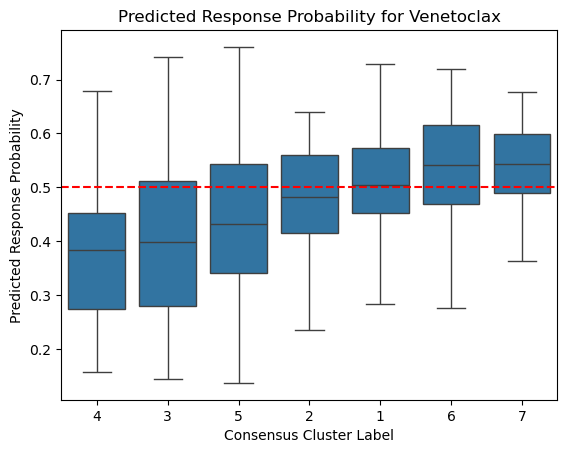

In [26]:
drug_name = 'Venetoclax'

_tmp = pd.DataFrame({'cluster': zdf_mds.cons_clusters.values, 'resp_prob': pred_dict[drug_name]})

plt.figure() 
sbn.boxplot(x='cluster', y='resp_prob', data=_tmp, showfliers=False, order=_tmp.groupby('cluster').mean().sort_values('resp_prob', ascending=True).head(10).index)
plt.axhline(0.5, color='red', linestyle='--')
plt.xlabel('Consensus Cluster Label')
plt.ylabel('Predicted Response Probability')
plt.title(f'Predicted Response Probability for {drug_name}')
plt.show() 

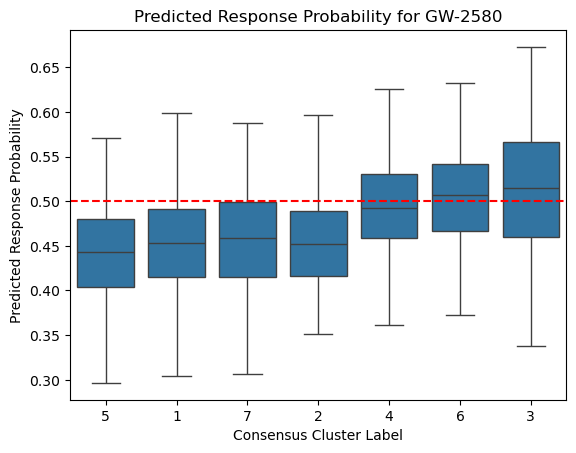

In [27]:
drug_name = 'GW-2580'

_tmp = pd.DataFrame({'cluster': zdf_mds.cons_clusters.values, 'resp_prob': pred_dict[drug_name]})

plt.figure() 
sbn.boxplot(x='cluster', y='resp_prob', data=_tmp, showfliers=False, order=_tmp.groupby('cluster').mean().sort_values('resp_prob', ascending=True).head(10).index)
plt.axhline(0.5, color='red', linestyle='--')
plt.xlabel('Consensus Cluster Label')
plt.ylabel('Predicted Response Probability')
plt.title(f'Predicted Response Probability for {drug_name}')
plt.show() 

In [8]:
res[lambda x: x.test_roc > 0.75].sort_values('prop_clus_resp', ascending=True)[lambda x: x.inhibitor == 'Venetoclax'].head(10)

,inhibitor,cluster,spearman_rho,pval,mean_prob_resp,prop_clus_resp,test_roc,x,y
690,Venetoclax,4,-0.272944,1.009217e-12,0.384405,0.179775,0.794444,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
689,Venetoclax,3,-0.205760,9.867313e-08,0.413607,0.336000,0.794444,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
686,Venetoclax,5,-0.061898,1.124037e-01,0.458936,0.361905,0.794444,"[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
691,Venetoclax,2,0.064052,1.004127e-01,0.501517,0.517241,0.794444,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
692,Venetoclax,6,0.115566,2.968145e-03,0.525808,0.645833,0.794444,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
687,Venetoclax,1,0.202255,1.636899e-07,0.520641,0.678788,0.794444,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."
688,Venetoclax,7,0.198601,2.749042e-07,0.545500,0.768116,0.794444,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3585209894973808, 0.40139770663583996, 0.39..."


In [10]:
res[lambda x: x.test_roc > 0.75].sort_values('prop_clus_resp', ascending=False).head(10)

,inhibitor,cluster,spearman_rho,pval,mean_prob_resp,prop_clus_resp,test_roc,x,y
562,AT7519,7,0.192088,6.762761e-07,0.529288,0.739130,0.751880,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.36634497948929834, 0.43314614256558037, 0.4..."
282,Bosutinib (SKI-606),7,0.229057,2.710942e-09,0.542733,0.739130,0.776042,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5233325136670888, 0.49829385252415265, 0.39..."
16,Dasatinib,7,0.215978,2.142623e-08,0.535031,0.724638,0.814493,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.4475799046157982, 0.4566532188585634, 0.502..."
688,Venetoclax,7,0.240624,3.911965e-10,0.535176,0.724638,0.827778,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."
437,17-AAG (Tanespimycin),3,0.307063,7.430132e-16,0.552747,0.720000,0.851852,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.4870816023747159, 0.5170827606580791, 0.601..."
93,Lapatinib,7,0.170490,1.079561e-05,0.535154,0.695652,0.761364,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.5535706512404518, 0.432539330766497, 0.4909..."
569,PRT062607,7,0.197376,3.263520e-07,0.517783,0.695652,0.840909,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.418406916013947, 0.493342809861096, 0.45237..."
667,KI20227,7,0.150455,1.057122e-04,0.526698,0.681159,0.785185,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.49317499842997636, 0.49638201239393764, 0.5..."
122,Rapamycin,3,0.332638,1.724344e-18,0.543585,0.680000,0.753333,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.451406328182346, 0.380478450088331, 0.46470..."
668,KI20227,3,0.220694,1.031846e-08,0.529583,0.664000,0.785185,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.49317499842997636, 0.49638201239393764, 0.5..."


In [11]:
ven_res = res[lambda x: x.test_roc > 0.75].sort_values('spearman_rho', ascending=False)[lambda x: x.inhibitor == 'Venetoclax'].head(10)
ven_res.head() 

,inhibitor,cluster,spearman_rho,pval,mean_prob_resp,prop_clus_resp,test_roc,x,y
688,Venetoclax,7,0.240624,3.911965e-10,0.535176,0.724638,0.827778,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."
692,Venetoclax,6,0.167993,1.456318e-05,0.529074,0.625000,0.827778,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."
687,Venetoclax,1,0.164180,2.281214e-05,0.493688,0.448485,0.827778,"[0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."
691,Venetoclax,2,0.028577,4.639468e-01,0.466525,0.431034,0.827778,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."
686,Venetoclax,5,-0.077350,4.715952e-02,0.437615,0.304762,0.827778,"[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.3372741953879469, 0.3707438288208978, 0.404..."


In [9]:
clus7_res = res[lambda x: (x.test_roc > 0.75) & (x.cluster == 6)].sort_values('prop_clus_resp', ascending=False).head(10)
clus7_res.head()[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].style.hide() 


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Venetoclax,6,0.525808,0.645833,0.115566,0.002968,0.794444
GW-2580,6,0.509021,0.604167,0.137083,0.000417,0.903704
SB-431542,6,0.508610,0.562500,0.147519,0.000144,0.778571
Vargetef,6,0.501065,0.520833,0.047884,0.219598,0.827068
PD173955,6,0.505924,0.500000,-0.094417,0.015325,0.766917


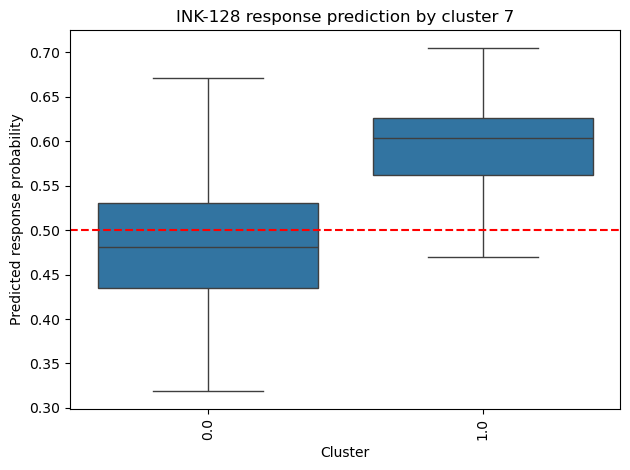

In [38]:
_tmp = pd.DataFrame({'cluster': clus7_res.x.values[1], 'pred_resp': clus7_res.y.values[1]})

plt.figure() 
sbn.boxplot(x='cluster', y='pred_resp', data=_tmp, showfliers=False)
plt.xticks(rotation=90)
plt.title('INK-128 response prediction by cluster 7')
plt.xlabel('Cluster')
plt.ylabel('Predicted response probability')
plt.tight_layout()
plt.axhline(0.5, color='red', linestyle='--', label='Threshold')
plt.show() 

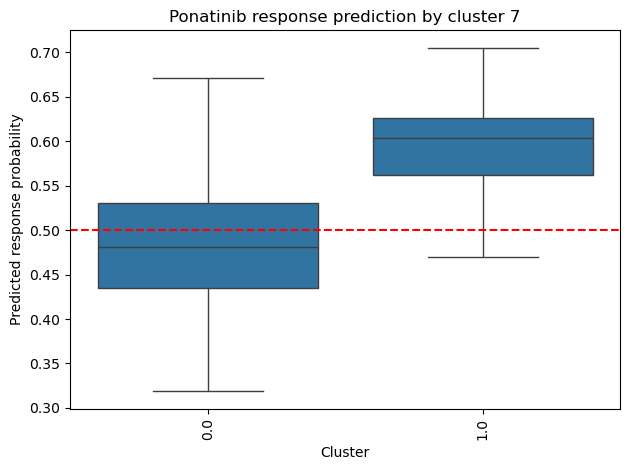

In [36]:
_tmp = pd.DataFrame({'cluster': clus7_res.x.values[1], 'pred_resp': clus7_res.y.values[1]})

plt.figure() 
sbn.boxplot(x='cluster', y='pred_resp', data=_tmp, showfliers=False)
plt.xticks(rotation=90)
plt.title('Ponatinib response prediction by cluster 7')
plt.xlabel('Cluster')
plt.ylabel('Predicted response probability')
plt.tight_layout()
plt.axhline(0.5, color='red', linestyle='--', label='Threshold')
plt.show() 

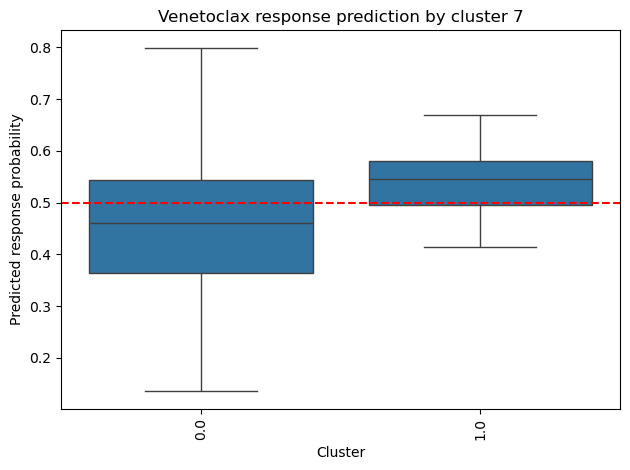

In [35]:
_tmp = pd.DataFrame({'cluster': ven_res.x.values[0], 'pred_resp': ven_res.y.values[0]})

plt.figure() 
sbn.boxplot(x='cluster', y='pred_resp', data=_tmp, showfliers=False)
plt.xticks(rotation=90)
plt.title('Venetoclax response prediction by cluster 7')
plt.xlabel('Cluster')
plt.ylabel('Predicted response probability')
plt.tight_layout()
plt.axhline(0.5, color='red', linestyle='--', label='Threshold')
plt.show() 

In [26]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 1)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Lapatinib,1,0.512626,0.618182,0.119770,0.002071,0.761364
YM-155,1,0.503025,0.545455,0.033565,0.389649,0.768182
SCH-772984,1,0.495685,0.503030,-0.005303,0.891927,0.858586
KI20227,1,0.490131,0.484848,-0.050854,0.192290,0.785185
Selumetinib (AZD6244),1,0.488867,0.466667,-0.018025,0.644162,0.795139


In [27]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 2)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Tivozanib (AV-951),2,0.500126,0.655172,0.077961,0.045437,0.844444
Bosutinib (SKI-606),2,0.498947,0.586207,0.026240,0.501295,0.776042
Vargetef,2,0.500126,0.500000,0.052171,0.181010,0.815789
Masitinib (AB-1010),2,0.495273,0.500000,0.043584,0.263889,0.766667
17-AAG (Tanespimycin),2,0.482138,0.482759,-0.012951,0.739999,0.851852


In [28]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 3)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
17-AAG (Tanespimycin),3,0.552747,0.720000,0.307063,0.000000,0.851852
Rapamycin,3,0.543585,0.680000,0.332638,0.000000,0.753333
Idelalisib,3,0.534224,0.664000,0.299596,0.000000,0.873913
KI20227,3,0.529583,0.664000,0.220694,0.000000,0.785185
YM-155,3,0.524318,0.656000,0.184762,0.000002,0.768182


In [29]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 4)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Lapatinib,4,0.516694,0.651685,0.102246,0.008623,0.761364
AT7519,4,0.515185,0.606742,0.131116,0.000741,0.751880
KI20227,4,0.495719,0.516854,-0.010409,0.789693,0.785185
YM-155,4,0.506298,0.516854,0.039372,0.312882,0.768182
SCH-772984,4,0.499639,0.516854,0.011856,0.761290,0.858586


In [30]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 5)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Trametinib (GSK1120212),5,0.522331,0.657143,0.194302,0.000000,0.866873
SCH-772984,5,0.529557,0.647619,0.172616,0.000008,0.858586
Selumetinib (AZD6244),5,0.524666,0.609524,0.147356,0.000147,0.795139
Bosutinib (SKI-606),5,0.506199,0.600000,0.079486,0.041366,0.776042
Idelalisib,5,0.494990,0.571429,0.061004,0.117695,0.873913


In [31]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 6)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
Venetoclax,6,0.529074,0.625000,0.167993,0.000015,0.827778
GW-2580,6,0.498685,0.520833,0.085086,0.028958,0.866667
Lapatinib,6,0.495988,0.500000,-0.007796,0.841663,0.761364
Vargetef,6,0.499822,0.500000,0.055036,0.158183,0.815789
Idelalisib,6,0.483842,0.437500,-0.019829,0.611377,0.873913


In [32]:
res[lambda x: (x.test_roc > 0.75) & (x.cluster == 7)].sort_values('prop_clus_resp', ascending=False)[['inhibitor', 'cluster', 'mean_prob_resp', 'prop_clus_resp', 'spearman_rho', 'pval', 'test_roc']].head().style.hide()


inhibitor,cluster,mean_prob_resp,prop_clus_resp,spearman_rho,pval,test_roc
AT7519,7,0.529288,0.739130,0.192088,0.000001,0.751880
Bosutinib (SKI-606),7,0.542733,0.739130,0.229057,0.000000,0.776042
Dasatinib,7,0.535031,0.724638,0.215978,0.000000,0.814493
Venetoclax,7,0.535176,0.724638,0.240624,0.000000,0.827778
PRT062607,7,0.517783,0.695652,0.197376,0.000000,0.840909
